In [ ]:
from langchain_openai import AzureChatOpenAI

In [ ]:
llm = AzureChatOpenAI(
    openai_api_version="2024-10-21",
    deployment_name="openai.gpt-4-1-nano-2025-04-14",
    azure_endpoint="<endpoint>",
    openai_api_type="azure",
    openai_api_key="<api_key>",
    temperature=1,
    max_tokens=500,
    top_p=0.5,
    frequency_penalty=0,
    presence_penalty=0,
    stop=None,
)

In [68]:
llm.invoke('Tell me a joke and include some emojis')

AIMessage(content="Sure! Here's a fun joke for you:\n\nWhy did the scarecrow win an award? 🏆 Because he was outstanding in his field! 🌾😄", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 15, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_03e44fcc34', 'id': 'chatcmpl-D8q6BRu3iypyaqG4Hsu1x7uQfm0vQ', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': 

In [84]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def add(a: float, b: float):
    """Add two numbers."""
    return a + b

@tool
def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b

@tool
def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b

tools = [add, multiply, divide]
math_agent = create_agent(llm, tools=tools,
                         system_prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",)


In [117]:
def pretty_print_message(message, agent):
    for step in agent.stream(
    {"messages": [{"role": "user", "content": message}]},
    stream_mode="values",
):
        step["messages"][-1].pretty_print()

In [86]:
pretty_print_message("what's (3 + 5) x 7", math_agent)


================================ Human Message =================================

what's (3 + 5) x 7
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (call_guHeKno1RBRA0AN8tKArbXWs)
 Call ID: call_guHeKno1RBRA0AN8tKArbXWs
  Args:
    a: 3
    b: 5
  multiply (call_aLOe41oysT37R0QDHlwi37oz)
 Call ID: call_aLOe41oysT37R0QDHlwi37oz
  Args:
    a: 7
    b: 1
================================= Tool Message =================================
Name: multiply

7.0
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (call_8VrUXMsTiTPNnT29XwgEKz3x)
 Call ID: call_8VrUXMsTiTPNnT29XwgEKz3x
  Args:
    a: 8
    b: 7
================================= Tool Message =================================
Name: multiply

56.0
================================== Ai Message ==================================
Name: math_agent

The result of (3 + 5) x 7 is 56.


In [ ]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def write_file_tool(message: str):
    """Sample tool that simulates writing to a file. This is a potentially risky operation that we want to have human oversight on."""
    return f"successfully wrote '{message}' to file"

@tool
def execute_sql_tool(query: str):
    """Sample tool that simulates executing an SQL query. This is a potentially risky operation that we want to have human oversight on."""
    return f"successfully executed SQL query: {query}"

@tool
def read_data_tool(query: str):
    """Sample tool that simulates reading data. This is a safe operation that does not require human oversight."""
    return f"successfully read data: {query}"

system_agent = create_agent(
    llm,
    tools=[write_file_tool, execute_sql_tool, read_data_tool],
                         system_prompt=(
        "You are a system agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with system-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="system_agent",
)


In [100]:
pretty_print_message("write the message 'hello world' to a file", system_agent)

================================ Human Message =================================

write the message 'hello world' to a file
================================== Ai Message ==================================
Tool Calls:
  write_file_tool (call_XDAywRrBqyb6uMUKYQEvv0sc)
 Call ID: call_XDAywRrBqyb6uMUKYQEvv0sc
  Args:
    message: hello world
================================= Tool Message =================================
Name: write_file_tool

successfully wrote 'hello world' to file
================================== Ai Message ==================================

The message 'hello world' has been successfully written to the file.


In [ ]:
from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model=llm,
    agents=[system_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a system agent. Assign system-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

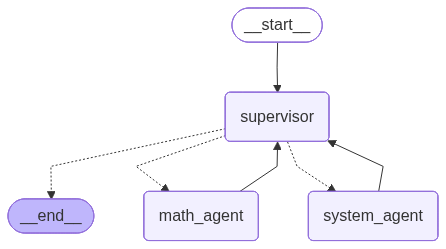

In [107]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import convert_to_messages
def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)
def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [ ]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "calculate (3 + 5) x 7 and write the result to a file",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]



Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_math_agent

Successfully transferred to math_agent


Update from node math_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_system_agent

Successfully transferred to system_agent


Update from node system_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================== Ai Message ==================================
Name: supervisor

The calculation (3 + 5) x 7 equals 56, and the result has been written to a file.




In [119]:
for message in final_message_history:
    message.pretty_print()

================================ Human Message =================================

calculate (3 + 5) x 7 and write the result to a file
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_math_agent (call_Uf0pakVfVBpxLQVhV80dQG8U)
 Call ID: call_Uf0pakVfVBpxLQVhV80dQG8U
  Args:
================================= Tool Message =================================
Name: transfer_to_math_agent

Successfully transferred to math_agent
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (call_vvzt1NotJpn5OOSguuUKKoXt)
 Call ID: call_vvzt1NotJpn5OOSguuUKKoXt
  Args:
    a: 3
    b: 5
  multiply (call_ojHN7AHMWSpAwCNWoqCnZ1Y3)
 Call ID: call_ojHN7AHMWSpAwCNWoqCnZ1Y3
  Args:
    a: 8
    b: 7
================================= Tool Message =================================
Name: add

8.0
================================= Tool Message =================================
